In [3]:
import numpy as np
import pandas as pd

In [8]:
import pandas as pd

# Load your CSV
df = pd.read_csv("census_georgia_counties_1.csv")

# Check columns and first rows
print(df.columns)
print(df.head())

# Clean column names
df.columns = df.columns.str.strip()

# Clean text fields
df["County"] = df["County"].astype(str).str.strip()
df["Attribute"] = df["Attribute"].astype(str).str.strip()

# Remove Georgia/statewide summary row if it exists
df = df[df["County"].str.lower() != "georgia"]

# Convert Value to numeric
df["Value"] = (
    df["Value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("%", "", regex=False)
)

df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Pivot from long format to wide format
df_wide = df.pivot_table(
    index=["FIPS_Code", "State", "County"],
    columns="Attribute",
    values="Value",
    aggfunc="first"
).reset_index()

# Remove column index name
df_wide.columns.name = None

# Preview final dataset
print(df_wide.head())
print(df_wide.shape)

# Save cleaned dataset
df_wide.to_csv("census_georgia_counties_cleaned_1.csv", index=False)

C:\Users\taylo\AppData\Local\Temp\ipykernel_15944\3743095426.py:4: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("census_georgia_counties_1.csv")


Index(['FIPS_Code', 'State', 'County', 'Attribute', 'Value'], dtype='object')
   FIPS_Code State              County                     Attribute    Value
0    13001.0    GA  Appling County, GA     Civilian_labor_force_2022   9693.0
1    13001.0    GA  Appling County, GA                 Employed_2022   9346.0
2    13001.0    GA  Appling County, GA               Unemployed_2022    347.0
3    13001.0    GA  Appling County, GA        Unemployment_rate_2022      3.6
4    13001.0    GA  Appling County, GA  Median_Household_Income_2022  51217.0
   FIPS_Code State               County  Civilian_labor_force_2022  \
0    13001.0    GA   Appling County, GA                     9693.0   
1    13003.0    GA  Atkinson County, GA                     4316.0   
2    13005.0    GA     Bacon County, GA                     4848.0   
3    13007.0    GA     Baker County, GA                     1116.0   
4    13009.0    GA   Baldwin County, GA                    17648.0   

   Employed_2022  Med_HH_Income_P

In [10]:
import pandas as pd

# Load CDC dataset
health = pd.read_csv("cdc_dataset.csv")

# Preview raw data
print("Raw shape:", health.shape)
print(health.head())
print(health.columns)

# Clean column names
health.columns = health.columns.str.strip()

# Filter to Georgia
health = health[health["StateAbbr"] == "GA"].copy()


# Keep only needed columns
health = health[["Year", "LocationName", "Measure", "Data_Value"]].copy()

# Clean county names
health["LocationName"] = (
    health["LocationName"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

# Convert values to numeric
health["Data_Value"] = pd.to_numeric(health["Data_Value"], errors="coerce")

# Choose health measures to keep
keep_measures = [
    "Obesity among adults aged >=18 years",
    "No leisure-time physical activity among adults aged >=18 years",
    "Current smoking among adults aged >=18 years",
    "Fair or poor self-rated health status among adults aged >=18 years"
]

health_filtered = health[health["Measure"].isin(keep_measures)].copy()

print("Filtered shape:", health_filtered.shape)
print(health_filtered.head())

# Pivot from long to wide format
health_wide = health_filtered.pivot_table(
    index="LocationName",
    columns="Measure",
    values="Data_Value",
    aggfunc="first"
).reset_index()

# Clean column names after pivot
health_wide.columns.name = None

health_wide = health_wide.rename(columns={
    "LocationName": "County",
    "Obesity among adults aged >=18 years": "adult_obesity_rate",
    "No leisure-time physical activity among adults aged >=18 years": "physical_inactivity_rate",
    "Current smoking among adults aged >=18 years": "adult_smoking_rate",
    "Fair or poor self-rated health status among adults aged >=18 years": "fair_or_poor_health_rate"
})

# Preview cleaned dataset
print("Cleaned shape:", health_wide.shape)
print(health_wide.head())

# Save cleaned CDC dataset
health_wide.to_csv("cdc_health_cleaned.csv", index=False)

print("Saved file: cdc_health_cleaned.csv")

Raw shape: (47948, 22)
   Year StateAbbr StateDesc LocationName DataSource  \
0  2022        GA   Georgia       Adrian      BRFSS   
1  2022        GA   Georgia        Alamo      BRFSS   
2  2022        GA   Georgia        Alamo      BRFSS   
3  2022        GA   Georgia  Ball Ground      BRFSS   
4  2022        GA   Georgia  Ball Ground      BRFSS   

                      Category  \
0              Health Outcomes   
1              Health Outcomes   
2              Health Outcomes   
3                   Disability   
4  Health-Related Social Needs   

                                             Measure Data_Value_Unit  \
0                    Diagnosed diabetes among adults               %   
1                                Stroke among adults               %   
2                                Stroke among adults               %   
3                    Hearing disability among adults               %   
4  Housing insecurity in the past 12 months among...               %   

        

In [13]:
import pandas as pd

# Load CDC dataset
health = pd.read_csv("cdc_dataset.csv")

# Preview raw data
print("Raw shape:", health.shape)
print(health.head())
print(health.columns)

# Clean column names
health.columns = health.columns.str.strip()

# Filter to Georgia
health = health[health["StateAbbr"] == "GA"].copy()

# Optional: use latest year available
latest_year = health["Year"].max()
health = health[health["Year"] == latest_year].copy()

print("Using year:", latest_year)

# Keep only needed columns
health = health[["Year", "LocationName", "Measure", "Data_Value"]].copy()

# Clean county names
health["LocationName"] = (
    health["LocationName"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

# Convert values to numeric
health["Data_Value"] = pd.to_numeric(health["Data_Value"], errors="coerce")

# Choose health measures to keep
keep_measures = [
    "Obesity among adults aged >=18 years",
    "No leisure-time physical activity among adults aged >=18 years",
    "Current smoking among adults aged >=18 years",
    "Fair or poor self-rated health status among adults aged >=18 years"
]

health_filtered = health[health["Measure"].isin(keep_measures)].copy()

print("Filtered shape:", health_filtered.shape)
print(health_filtered.head())

# Pivot from long to wide format
health_wide = health_filtered.pivot_table(
    index="LocationName",
    columns="Measure",
    values="Data_Value",
    aggfunc="first"
).reset_index()

# Clean column names after pivot
health_wide.columns.name = None

health_wide = health_wide.rename(columns={
    "LocationName": "County",
    "Obesity among adults aged >=18 years": "adult_obesity_rate",
    "No leisure-time physical activity among adults aged >=18 years": "physical_inactivity_rate",
    "Current smoking among adults aged >=18 years": "adult_smoking_rate",
    "Fair or poor self-rated health status among adults aged >=18 years": "fair_or_poor_health_rate"
})

# Preview cleaned dataset
print("Cleaned shape:", health_wide.shape)
print(health_wide.head())

# Save cleaned CDC dataset
health_wide.to_csv("cdc_health_cleaned.csv", index=False)

print("Saved file: cdc_health_cleaned.csv")

Raw shape: (47948, 22)
   Year StateAbbr StateDesc LocationName DataSource  \
0  2022        GA   Georgia       Adrian      BRFSS   
1  2022        GA   Georgia        Alamo      BRFSS   
2  2022        GA   Georgia        Alamo      BRFSS   
3  2022        GA   Georgia  Ball Ground      BRFSS   
4  2022        GA   Georgia  Ball Ground      BRFSS   

                      Category  \
0              Health Outcomes   
1              Health Outcomes   
2              Health Outcomes   
3                   Disability   
4  Health-Related Social Needs   

                                             Measure Data_Value_Unit  \
0                    Diagnosed diabetes among adults               %   
1                                Stroke among adults               %   
2                                Stroke among adults               %   
3                    Hearing disability among adults               %   
4  Housing insecurity in the past 12 months among...               %   

        

In [14]:
import pandas as pd

health = pd.read_csv("cdc_dataset.csv")
health.columns = health.columns.str.strip()

health = health[health["StateAbbr"] == "GA"].copy()

print(health["Year"].unique())
print(health["Measure"].dropna().unique()[:50])

[2022]
['Diagnosed diabetes among adults' 'Stroke among adults'
 'Hearing disability among adults'
 'Housing insecurity in the past 12 months among adults'
 'Short sleep duration among adults'
 'Independent living disability among adults'
 'Feeling socially isolated among adults'
 'Lack of reliable transportation in the past 12 months among adults'
 'No leisure-time physical activity among adults'
 'Mammography use among women aged 50-74 years'
 'Frequent mental distress among adults'
 'Mobility disability among adults' 'Obesity among adults'
 'Frequent physical distress among adults'
 'Self-care disability among adults'
 'Utility services shut-off threat in the past 12 months among adults'
 'All teeth lost among adults aged >=65 years'
 'Vision disability among adults'
 'Current lack of health insurance among adults aged 18-64 years'
 'Arthritis among adults' 'Binge drinking among adults'
 'Cancer (non-skin) or melanoma among adults'
 'Current asthma among adults' 'Coronary heart dise

In [15]:
import pandas as pd

health = pd.read_csv("cdc_dataset.csv")
health.columns = health.columns.str.strip()

health = health[health["StateAbbr"] == "GA"].copy()

latest_year = health["Year"].max()
health = health[health["Year"] == latest_year].copy()

health = health[["Year", "LocationName", "Measure", "Data_Value"]].copy()

health["LocationName"] = (
    health["LocationName"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

health["Data_Value"] = pd.to_numeric(health["Data_Value"], errors="coerce")
health = health.dropna(subset=["Data_Value"])

# Instead of exact names, use keyword matching
keywords = ["obesity", "physical activity", "smoking", "poor health"]

health_filtered = health[
    health["Measure"].str.lower().str.contains("|".join(keywords), na=False)
].copy()

print("Filtered shape:", health_filtered.shape)
print(health_filtered["Measure"].unique())

health_wide = health_filtered.pivot_table(
    index="LocationName",
    columns="Measure",
    values="Data_Value",
    aggfunc="mean"
).reset_index()

health_wide.columns.name = None
health_wide = health_wide.rename(columns={"LocationName": "County"})

print(health_wide.head())
print(health_wide.shape)

health_wide.to_csv("cdc_health_cleaned.csv", index=False)

Filtered shape: (3996, 4)
['No leisure-time physical activity among adults' 'Obesity among adults'
 'Current cigarette smoking among adults']
        County  Current cigarette smoking among adults  \
0    abbeville                                   26.35   
1      acworth                                   13.75   
2  adairsville                                   13.95   
3         adel                                   19.50   
4       adrian                                   19.70   

   No leisure-time physical activity among adults  Obesity among adults  
0                                           38.10                 48.25  
1                                           21.40                 31.15  
2                                           22.30                 36.70  
3                                           33.75                 42.25  
4                                           34.10                 40.35  
(664, 4)


In [23]:
import pandas as pd

# =========================
# 1. Load both datasets
# =========================

census = pd.read_csv("census_georgia_counties_cleaned_1.csv")
cdc = pd.read_csv("cdc_health_cleaned.csv")

print("Census shape:", census.shape)
print("CDC shape:", cdc.shape)

print(census.head())
print(cdc.head())


# =========================
# 2. Clean column names
# =========================

census.columns = census.columns.str.strip()
cdc.columns = cdc.columns.str.strip()


# =========================
# 3. Standardize county names
# =========================

census["County"] = (
    census["County"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

cdc["County"] = (
    cdc["County"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)


# =========================
# 4. Check county overlap
# =========================

census_counties = set(census["County"])
cdc_counties = set(cdc["County"])

common_counties = census_counties.intersection(cdc_counties)

print("Census counties:", len(census_counties))
print("CDC counties:", len(cdc_counties))
print("Matching counties:", len(common_counties))

print("Example matching counties:", list(common_counties)[:10])


# =========================
# 5. Identify non-matching counties
# =========================

print("In Census but not CDC:")
print(sorted(census_counties - cdc_counties)[:20])

print("In CDC but not Census:")
print(sorted(cdc_counties - census_counties)[:20])


# =========================
# 6. Merge datasets
# =========================

final_df = census.merge(
    cdc,
    on="County",
    how="inner"
)

print("Final merged shape:", final_df.shape)
print(final_df.head())


# =========================
# 7. Check missing values
# =========================

print(final_df.isnull().sum())


# =========================
# 8. Save final dataset
# =========================

final_df.to_csv("final_capstone_dataset.csv", index=False)

print("Saved file: final_capstone_dataset.csv")

Census shape: (159, 9)
CDC shape: (664, 4)
   FIPS_Code State               County  Civilian_labor_force_2022  \
0    13001.0    GA   Appling County, GA                     9693.0   
1    13003.0    GA  Atkinson County, GA                     4316.0   
2    13005.0    GA     Bacon County, GA                     4848.0   
3    13007.0    GA     Baker County, GA                     1116.0   
4    13009.0    GA   Baldwin County, GA                    17648.0   

   Employed_2022  Med_HH_Income_Percent_of_State_Total_2022  \
0         9346.0                                       70.4   
1         4193.0                                       63.3   
2         4700.0                                       63.3   
3         1070.0                                       68.9   
4        16918.0                                       68.6   

   Median_Household_Income_2022  Unemployed_2022  Unemployment_rate_2022  
0                       51217.0            347.0                     3.6  
1      

In [24]:
print(census["County"].head(10))
print(cdc["County"].head(10))

0     appling, ga
1    atkinson, ga
2       bacon, ga
3       baker, ga
4     baldwin, ga
5       banks, ga
6      barrow, ga
7      bartow, ga
8    ben hill, ga
9     berrien, ga
Name: County, dtype: object
0      abbeville
1        acworth
2    adairsville
3           adel
4         adrian
5          ailey
6          alamo
7        alapaha
8         albany
9     allenhurst
Name: County, dtype: object


In [25]:
print(set(census["County"]) - set(cdc["County"]))
print(set(cdc["County"]) - set(census["County"]))

{'peach, ga', 'appling, ga', 'terrell, ga', 'emanuel, ga', 'heard, ga', 'ware, ga', 'jasper, ga', 'jefferson, ga', 'grady, ga', 'lumpkin, ga', 'carroll, ga', 'mitchell, ga', 'crisp, ga', 'clayton, ga', 'johnson, ga', 'chattooga, ga', 'bulloch, ga', 'white, ga', 'rabun, ga', 'baker, ga', 'cobb, ga', 'bartow, ga', 'bibb, ga', 'wilkes, ga', 'monroe, ga', 'miller, ga', 'taliaferro, ga', 'dade, ga', 'fannin, ga', 'rockdale, ga', 'fulton, ga', 'lee, ga', 'sumter, ga', 'calhoun, ga', 'douglas, ga', 'houston, ga', 'turner, ga', 'lamar, ga', 'dawson, ga', 'irwin, ga', 'cook, ga', 'hall, ga', 'henry, ga', 'lowndes, ga', 'clarke, ga', 'effingham, ga', 'glascock, ga', 'wilkinson, ga', 'troup, ga', 'elbert, ga', 'echols, ga', 'walker, ga', 'muscogee, ga', 'coweta, ga', 'quitman, ga', 'union, ga', 'dooly, ga', 'bryan, ga', 'banks, ga', 'crawford, ga', 'taylor, ga', 'harris, ga', 'baldwin, ga', 'long, ga', 'oconee, ga', 'dekalb, ga', 'mcduffie, ga', 'glynn, ga', 'camden, ga', 'macon, ga', 'clinch, ga

In [26]:
census["County"] = (
    census["County"]
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

cdc["County"] = (
    cdc["County"]
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

In [27]:
final_df = census.merge(cdc, on="County", how="inner")

print(final_df.shape)
print(final_df.head())

(0, 12)
Empty DataFrame
Columns: [FIPS_Code, State, County, Civilian_labor_force_2022, Employed_2022, Med_HH_Income_Percent_of_State_Total_2022, Median_Household_Income_2022, Unemployed_2022, Unemployment_rate_2022, Current cigarette smoking among adults, No leisure-time physical activity among adults, Obesity among adults]
Index: []


In [28]:
print(census["County"].head())

0     appling, ga
1    atkinson, ga
2       bacon, ga
3       baker, ga
4     baldwin, ga
Name: County, dtype: object


In [29]:
print(cdc["County"].head())

0      abbeville
1        acworth
2    adairsville
3           adel
4         adrian
Name: County, dtype: object


In [30]:
import pandas as pd

# Load county-level CDC PLACES dataset
cdc = pd.read_csv("PLACES__Local_Data_for_Better_Health,_County_Data_2024_release_20260504.csv")

# Preview raw dataset
print("Raw CDC shape:", cdc.shape)
print(cdc.head())
print(cdc.columns)

# Clean column names
cdc.columns = cdc.columns.str.strip()

# Filter to Georgia
cdc = cdc[cdc["StateAbbr"] == "GA"].copy()

# Use latest year available
latest_year = cdc["Year"].max()
cdc = cdc[cdc["Year"] == latest_year].copy()

print("Using year:", latest_year)

# Keep only columns needed for cleaning/pivoting
cdc = cdc[["Year", "StateAbbr", "LocationName", "Measure", "Data_Value"]].copy()

# Clean county names
cdc["County"] = (
    cdc["LocationName"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)

# Convert Data_Value to numeric
cdc["Data_Value"] = pd.to_numeric(cdc["Data_Value"], errors="coerce")

# Drop rows where Data_Value is missing
cdc = cdc.dropna(subset=["Data_Value"])

# Preview available measures so you can verify names
print("Available measures:")
print(cdc["Measure"].dropna().unique()[:100])

# Keep selected health measures using keyword matching
keywords = [
    "obesity",
    "physical activity",
    "smoking",
    "poor health"
]

cdc_filtered = cdc[
    cdc["Measure"].str.lower().str.contains("|".join(keywords), na=False)
].copy()

print("Filtered CDC shape:", cdc_filtered.shape)
print(cdc_filtered[["County", "Measure", "Data_Value"]].head())

# Pivot from long format to wide format
cdc_wide = cdc_filtered.pivot_table(
    index="County",
    columns="Measure",
    values="Data_Value",
    aggfunc="mean"
).reset_index()

# Remove column index name
cdc_wide.columns.name = None

# Rename long measure columns into simpler variable names
rename_map = {
    "Obesity among adults aged >=18 years": "adult_obesity_rate",
    "No leisure-time physical activity among adults aged >=18 years": "physical_inactivity_rate",
    "Current smoking among adults aged >=18 years": "adult_smoking_rate",
    "Fair or poor self-rated health status among adults aged >=18 years": "fair_or_poor_health_rate"
}

cdc_wide = cdc_wide.rename(columns=rename_map)

# Preview cleaned dataset
print("Cleaned CDC shape:", cdc_wide.shape)
print(cdc_wide.head())

# Save cleaned CDC dataset
cdc_wide.to_csv("cdc_places_county_cleaned.csv", index=False)

print("Saved file: cdc_places_county_cleaned.csv")

Raw CDC shape: (11448, 22)
   Year StateAbbr StateDesc LocationName DataSource         Category  \
0  2022        GA   Georgia         Bibb      BRFSS       Disability   
1  2022        GA   Georgia       Camden      BRFSS       Disability   
2  2022        GA   Georgia    Dougherty      BRFSS  Health Outcomes   
3  2022        GA   Georgia      Lowndes      BRFSS  Health Outcomes   
4  2022        GA   Georgia     Mitchell      BRFSS  Health Outcomes   

                           Measure Data_Value_Unit   Data_Value_Type  \
0  Hearing disability among adults               %  Crude prevalence   
1  Hearing disability among adults               %  Crude prevalence   
2              Stroke among adults               %  Crude prevalence   
3              Stroke among adults               %  Crude prevalence   
4              Stroke among adults               %  Crude prevalence   

   Data_Value  ...  Low_Confidence_Limit  High_Confidence_Limit  \
0         7.2  ...                   6.4

In [32]:
import pandas as pd

# =========================
# 1. Load cleaned datasets
# =========================

census = pd.read_csv("census_georgia_counties_cleaned_1.csv")
cdc = pd.read_csv("cdc_places_county_cleaned.csv")

print("Census shape:", census.shape)
print("CDC shape:", cdc.shape)

print(census.head())
print(cdc.head())


# =========================
# 2. Clean column names
# =========================

census.columns = census.columns.str.strip()
cdc.columns = cdc.columns.str.strip()


# =========================
# 3. Standardize County names
# =========================

census["County"] = (
    census["County"]
    .astype(str)
    .str.lower()
    .str.replace(", ga", "", regex=False)
    .str.replace(" county", "", regex=False)
    .str.strip()
)

cdc["County"] = (
    cdc["County"]
    .astype(str)
    .str.lower()
    .str.replace(" county", "", regex=False)
    .str.strip()
)


# =========================
# 4. Check overlap (IMPORTANT)
# =========================

common = set(census["County"]).intersection(set(cdc["County"]))

print("Census counties:", census["County"].nunique())
print("CDC counties:", cdc["County"].nunique())
print("Matching counties:", len(common))

print("Example matches:", list(common)[:10])


# =========================
# 5. Merge datasets
# =========================

final_df = census.merge(cdc, on="County", how="inner")

print("Final merged shape:", final_df.shape)
print(final_df.head())


# =========================
# 6. Check for missing values
# =========================

print(final_df.isnull().sum())


# =========================
# 7. Save final dataset
# =========================

final_df.to_csv("final_capstone_dataset.csv", index=False)

print("Saved file: final_capstone_dataset.csv")

Census shape: (159, 9)
CDC shape: (159, 4)
   FIPS_Code State               County  Civilian_labor_force_2022  \
0    13001.0    GA   Appling County, GA                     9693.0   
1    13003.0    GA  Atkinson County, GA                     4316.0   
2    13005.0    GA     Bacon County, GA                     4848.0   
3    13007.0    GA     Baker County, GA                     1116.0   
4    13009.0    GA   Baldwin County, GA                    17648.0   

   Employed_2022  Med_HH_Income_Percent_of_State_Total_2022  \
0         9346.0                                       70.4   
1         4193.0                                       63.3   
2         4700.0                                       63.3   
3         1070.0                                       68.9   
4        16918.0                                       68.6   

   Median_Household_Income_2022  Unemployed_2022  Unemployment_rate_2022  
0                       51217.0            347.0                     3.6  
1      

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# =========================
# 1. Load final dataset
# =========================

df = pd.read_csv("final_capstone_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)


# =========================
# 2. Select target variable
# =========================

target = "fair_or_poor_health_rate"

# Select numeric columns only
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Drop rows missing target
numeric_df = numeric_df.dropna(subset=[target])

# Separate X and y
X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# Fill missing predictor values with median
X = X.fillna(X.median())


# =========================
# 3. Correlation analysis
# =========================

correlations = numeric_df.corr()[target].sort_values(ascending=False)

print("Correlation with target variable:")
print(correlations)

# Plot correlation values
plt.figure(figsize=(10, 6))
correlations.drop(target).plot(kind="bar")
plt.title("Correlation with Fair or Poor Health Rate")
plt.xlabel("Variables")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


# =========================
# 4. Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# =========================
# 5. Linear Regression
# =========================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5

print("Linear Regression R²:", linear_r2)
print("Linear Regression RMSE:", linear_rmse)


# =========================
# 6. Random Forest Regression
# =========================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5

print("Random Forest R²:", rf_r2)
print("Random Forest RMSE:", rf_rmse)


# =========================
# 7. Feature importance
# =========================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# =========================
# 8. Save outputs
# =========================

correlations.to_csv("correlation_results.csv")
importance.to_csv("feature_importance_results.csv", index=False)

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "R2": [linear_r2, rf_r2],
    "RMSE": [linear_rmse, rf_rmse]
})

print(model_results)

model_results.to_csv("model_performance_results.csv", index=False)

print("Saved: correlation_results.csv")
print("Saved: feature_importance_results.csv")
print("Saved: model_performance_results.csv")

Dataset shape: (159, 12)
   FIPS_Code State    County  Civilian_labor_force_2022  Employed_2022  \
0    13001.0    GA   appling                     9693.0         9346.0   
1    13003.0    GA  atkinson                     4316.0         4193.0   
2    13005.0    GA     bacon                     4848.0         4700.0   
3    13007.0    GA     baker                     1116.0         1070.0   
4    13009.0    GA   baldwin                    17648.0        16918.0   

   Med_HH_Income_Percent_of_State_Total_2022  Median_Household_Income_2022  \
0                                       70.4                       51217.0   
1                                       63.3                       46060.0   
2                                       63.3                       46044.0   
3                                       68.9                       50129.0   
4                                       68.6                       49883.0   

   Unemployed_2022  Unemployment_rate_2022  \
0            34

KeyError: ['fair_or_poor_health_rate']

In [34]:
print("Target exists:", "fair_or_poor_health_rate" in df.columns)

Target exists: False


Dataset shape: (159, 12)
   FIPS_Code State    County  Civilian_labor_force_2022  Employed_2022  \
0    13001.0    GA   appling                     9693.0         9346.0   
1    13003.0    GA  atkinson                     4316.0         4193.0   
2    13005.0    GA     bacon                     4848.0         4700.0   
3    13007.0    GA     baker                     1116.0         1070.0   
4    13009.0    GA   baldwin                    17648.0        16918.0   

   Med_HH_Income_Percent_of_State_Total_2022  Median_Household_Income_2022  \
0                                       70.4                       51217.0   
1                                       63.3                       46060.0   
2                                       63.3                       46044.0   
3                                       68.9                       50129.0   
4                                       68.6                       49883.0   

   Unemployed_2022  Unemployment_rate_2022  \
0            34

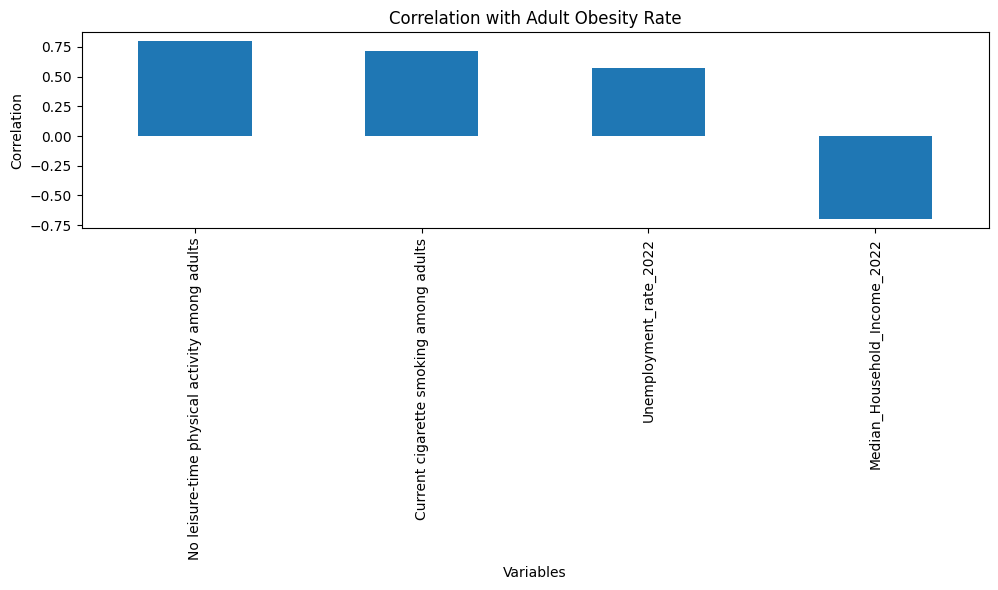

Linear Regression R²: 0.7900697550194411
Linear Regression RMSE: 1.6130618750795818
Random Forest R²: 0.756270026740812
Random Forest RMSE: 1.7380729109418884
Feature Importance:
                                          Feature  Importance
3  No leisure-time physical activity among adults    0.523019
0                    Median_Household_Income_2022    0.231628
2          Current cigarette smoking among adults    0.141680
1                          Unemployment_rate_2022    0.103672


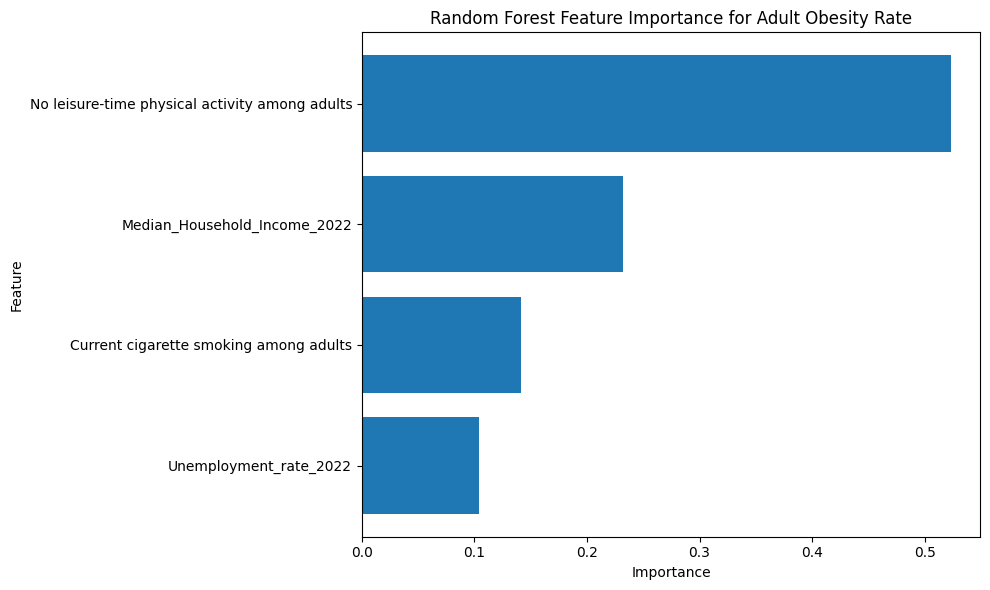

                      Model       R2      RMSE
0         Linear Regression  0.79007  1.613062
1  Random Forest Regression  0.75627  1.738073
Saved analysis outputs.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load final dataset
df = pd.read_csv("final_capstone_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns.tolist())

# Set target variable
target = "Obesity among adults"

# Select predictors
features = [
    "Median_Household_Income_2022",
    "Unemployment_rate_2022",
    "Current cigarette smoking among adults",
    "No leisure-time physical activity among adults"
]

# Keep only needed columns
model_df = df[features + [target]].copy()

# Drop missing values
model_df = model_df.dropna()

# Correlation analysis
correlations = model_df.corr()[target].sort_values(ascending=False)

print("Correlation with target variable:")
print(correlations)

# Correlation bar chart
plt.figure(figsize=(10, 6))
correlations.drop(target).plot(kind="bar")
plt.title("Correlation with Adult Obesity Rate")
plt.xlabel("Variables")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# Separate predictors and target
X = model_df[features]
y = model_df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5

print("Linear Regression R²:", linear_r2)
print("Linear Regression RMSE:", linear_rmse)

# Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5

print("Random Forest R²:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

# Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance for Adult Obesity Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save outputs
correlations.to_csv("correlation_results.csv")
importance.to_csv("feature_importance_results.csv", index=False)

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "R2": [linear_r2, rf_r2],
    "RMSE": [linear_rmse, rf_rmse]
})

print(model_results)

model_results.to_csv("model_performance_results.csv", index=False)

print("Saved analysis outputs.")

In [36]:
print(correlations)

Obesity among adults                              1.000000
No leisure-time physical activity among adults    0.797009
Current cigarette smoking among adults            0.711314
Unemployment_rate_2022                            0.569574
Median_Household_Income_2022                     -0.699606
Name: Obesity among adults, dtype: float64


In [37]:
print("Linear Regression R²:", linear_r2)
print("Linear Regression RMSE:", linear_rmse)

Linear Regression R²: 0.7900697550194411
Linear Regression RMSE: 1.6130618750795818


In [38]:
print("Random Forest R²:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

Random Forest R²: 0.756270026740812
Random Forest RMSE: 1.7380729109418884


In [39]:
print(importance)

                                          Feature  Importance
3  No leisure-time physical activity among adults    0.523019
0                    Median_Household_Income_2022    0.231628
2          Current cigarette smoking among adults    0.141680
1                          Unemployment_rate_2022    0.103672
